## Importing Libraries

In [81]:
# import the libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

sns.set(style="darkgrid")
plt.rcParams["figure.figsize"] = (10,6)


## Importing Dataset

In [28]:
df = pd.read_csv('lagos_traffic.csv')
df.head()

,Date,Time,Day_of_Week,Road_Name,Weather_Condition,Time_of_Day,Traffic_Volume,Delay_Minutes,Congestion_Level
0,1/1/2026,0:00,Thursday,Ikorodu Road,Clear,Night,510,12.4,Low / Free Flow
1,1/1/2026,1:00,Thursday,Third Mainland Bridge,Clear,Night,820,9.1,Low / Free Flow
2,1/1/2026,2:00,Thursday,Lekki-Epe Expressway,Light Rain,Night,640,19.5,Low / Free Flow
3,1/1/2026,3:00,Thursday,Apapa-Oshodi Expressway,Clear,Night,410,11.2,Low / Free Flow
4,1/1/2026,4:00,Thursday,Third Mainland Bridge,Clear,Night,910,15.6,Low / Free Flow


## Data Exploration

In [29]:
df

,Date,Time,Day_of_Week,Road_Name,Weather_Condition,Time_of_Day,Traffic_Volume,Delay_Minutes,Congestion_Level
0,1/1/2026,0:00,Thursday,Ikorodu Road,Clear,Night,510,12.4,Low / Free Flow
1,1/1/2026,1:00,Thursday,Third Mainland Bridge,Clear,Night,820,9.1,Low / Free Flow
2,1/1/2026,2:00,Thursday,Lekki-Epe Expressway,Light Rain,Night,640,19.5,Low / Free Flow
3,1/1/2026,3:00,Thursday,Apapa-Oshodi Expressway,Clear,Night,410,11.2,Low / Free Flow
4,1/1/2026,4:00,Thursday,Third Mainland Bridge,Clear,Night,910,15.6,Low / Free Flow
...,...,...,...,...,...,...,...,...,...
95,1/4/2026,23:00,Sunday,Apapa-Oshodi Expressway,Clear,Night,950,11.8,Low / Free Flow
96,1/5/2026,0:00,Monday,Third Mainland Bridge,Clear,Night,880,10.1,Low / Free Flow
97,1/5/2026,1:00,Monday,Lekki-Epe Expressway,Clear,Night,740,8.4,Low / Free Flow
98,1/5/2026,2:00,Monday,Ikorodu Road,Clear,Night,510,9.1,Low / Free Flow


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               100 non-null    object 
 1   Time               100 non-null    object 
 2   Day_of_Week        100 non-null    object 
 3   Road_Name          100 non-null    object 
 4   Weather_Condition  100 non-null    object 
 5   Time_of_Day        100 non-null    object 
 6   Traffic_Volume     100 non-null    int64  
 7   Delay_Minutes      100 non-null    float64
 8   Congestion_Level   100 non-null    object 
dtypes: float64(1), int64(1), object(7)
memory usage: 7.2+ KB


In [31]:
df.isnull()

,Date,Time,Day_of_Week,Road_Name,Weather_Condition,Time_of_Day,Traffic_Volume,Delay_Minutes,Congestion_Level
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
95,False,False,False,False,False,False,False,False,False
96,False,False,False,False,False,False,False,False,False
97,False,False,False,False,False,False,False,False,False
98,False,False,False,False,False,False,False,False,False


In [32]:
df.dtypes

Date                  object
Time                  object
Day_of_Week           object
Road_Name             object
Weather_Condition     object
Time_of_Day           object
Traffic_Volume         int64
Delay_Minutes        float64
Congestion_Level      object
dtype: object

In [33]:
df.describe()

,Traffic_Volume,Delay_Minutes
count,100.000000,100.00000
mean,1811.100000,57.46300
std,863.842596,44.15892
min,410.000000,8.40000
25%,1100.000000,15.55000
50%,1850.000000,57.50000
75%,2392.500000,88.17500
max,3720.000000,168.40000


In [34]:
df.all()

Date                 True
Time                 True
Day_of_Week          True
Road_Name            True
Weather_Condition    True
Time_of_Day          True
Traffic_Volume       True
Delay_Minutes        True
Congestion_Level     True
dtype: bool

## Data Visualization

## A. Congestion Level Distribution

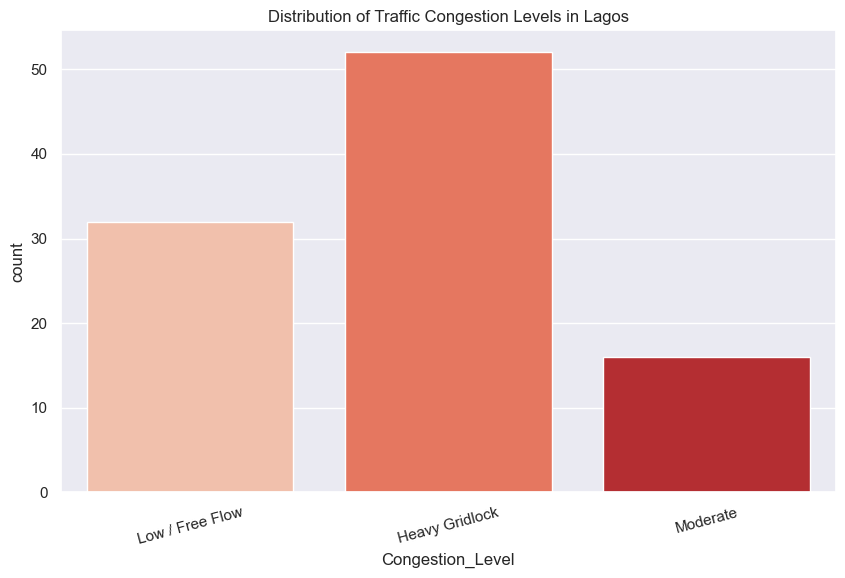

In [38]:
sns.countplot(data=df, x="Congestion_Level", palette="Reds")
plt.title("Distribution of Traffic Congestion Levels in Lagos")
plt.xticks(rotation=15)
plt.show()

### Insight : Heavy gridlock dominates peak hours

## B. Traffic Volume By Road

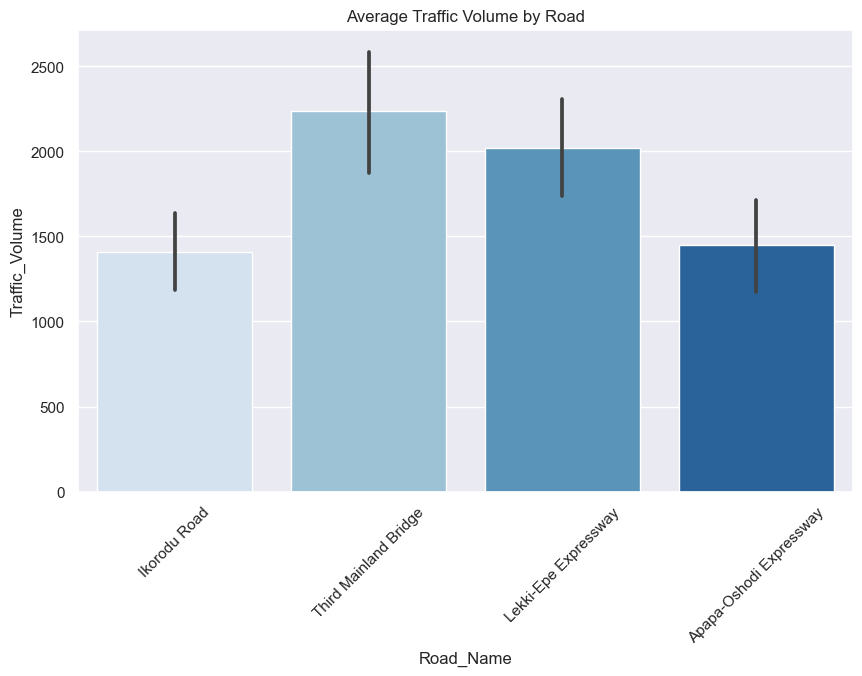

In [43]:
sns.barplot(    
    data=df,
x="Road_Name",
y="Traffic_Volume",
estimator=np.mean,
palette="Blues"
)

plt.title("Average Traffic Volume by Road")
plt.xticks(rotation=45)
plt.show()

### Insight: Third Mainland Bridge and Lekki-Epe show highest traffic load.

## C. Hour vs Traffic Volume (Line Plot)

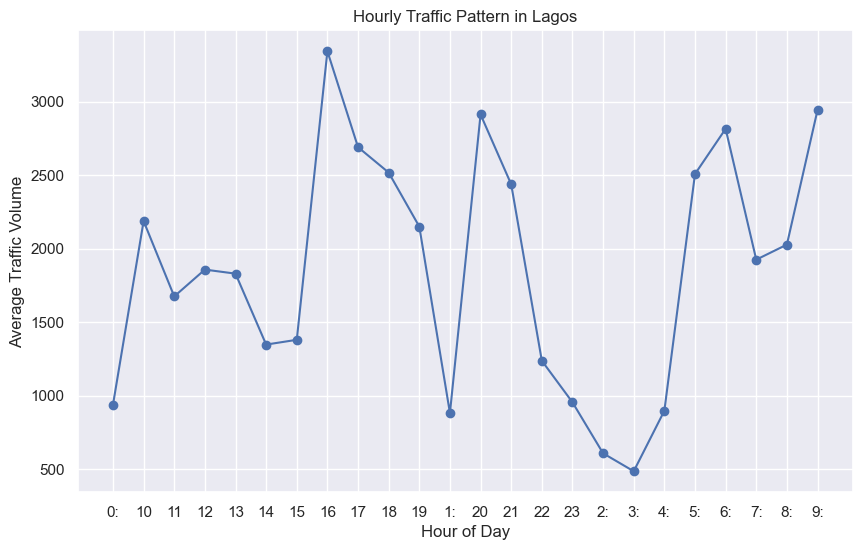

In [62]:
df["Hour"] = df["Time"].str[:2].astype(object)

hourly = df.groupby("Hour")["Traffic_Volume"].mean()

plt.plot(hourly.index, hourly.values, marker="o")
plt.title("Hourly Traffic Pattern in Lagos")
plt.xlabel("Hour of Day")
plt.ylabel("Average Traffic Volume")
plt.show()


### Insight: The Line Plot above shows the peak congestions are between 6 - 9 AM and 4 - 8 PM

## D. Average Delay (Minutes) By Time of Day (Bar Plot)

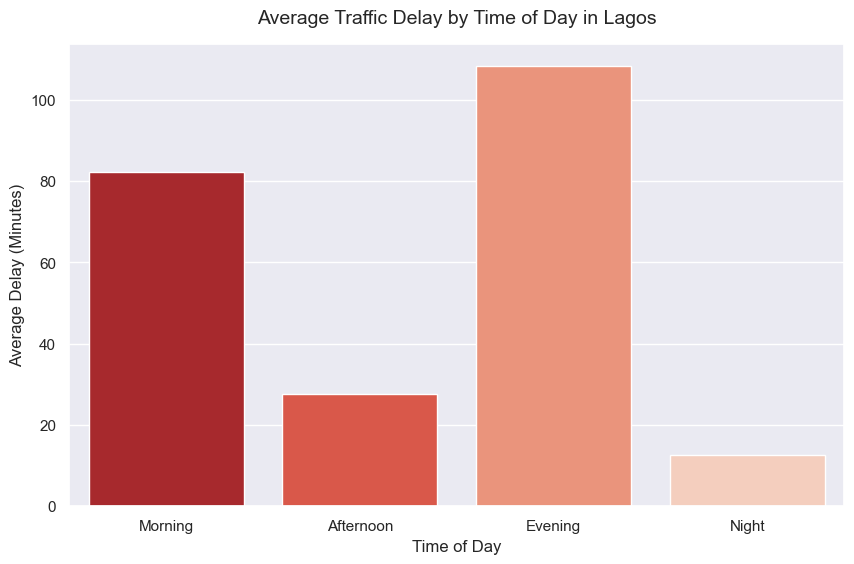

In [78]:
plt.figure() 
sns.barplot( 
    x="Time_of_Day", 
    y="Delay_Minutes", 
    data=df,
    order=["Morning", "Afternoon", "Evening", "Night"], 
    palette="Reds_r",
    errorbar=None, 
) 
plt.title("Average Traffic Delay by Time of Day in Lagos", fontsize=14, pad=15) 
plt.xlabel("Time of Day", fontsize=12)
plt.ylabel("Average Delay (Minutes)", fontsize=12) 
plt.show()

### Insight : This visual highlights the massive, twin peak occurring during the morning and evening rush hours, while the stark drop-off during mid-day and late-night frames.

## E. Weather_condition vs Delay (Scatter Plot)

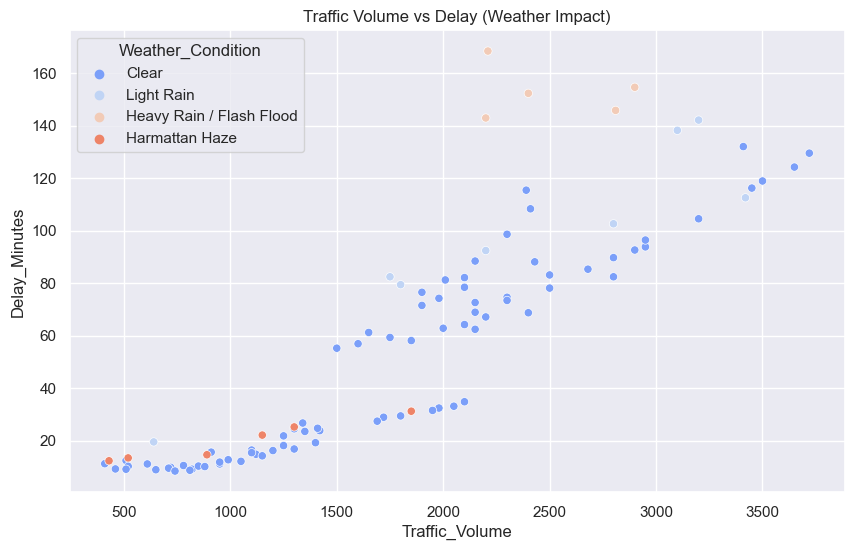

In [85]:
sns.scatterplot(
data=df,
x="Traffic_Volume",
y="Delay_Minutes",
hue="Weather_Condition",
palette="coolwarm"
)

plt.title("Traffic Volume vs Delay (Weather Impact)")
plt.show()

### Insight : Rain increases delay significantly even at moderate traffic

## F. Traffic Volume vs Delay (Regression Plot)

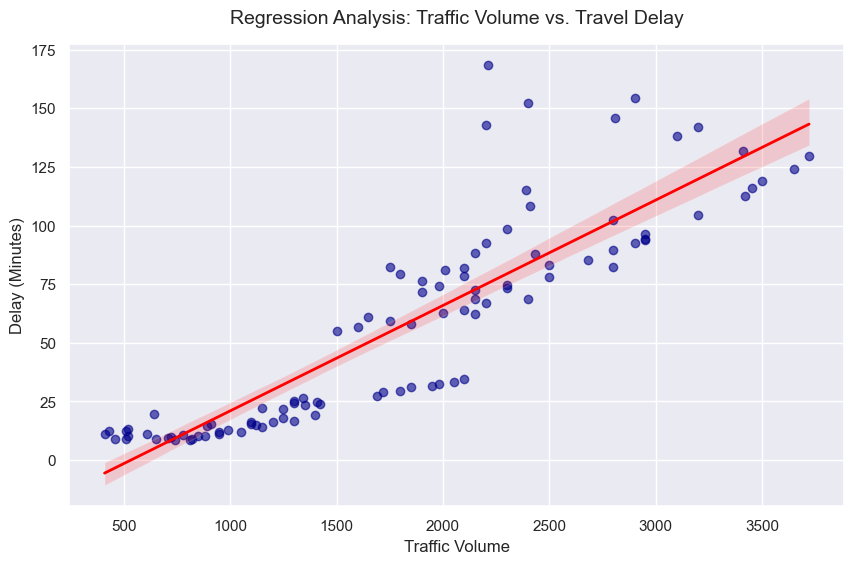

In [86]:
plt.figure() 
sns.regplot( 
    x="Traffic_Volume", 
    y="Delay_Minutes",
    data=df, 
    scatter_kws={"alpha": 0.6, "color": "darkblue"},
    line_kws={"color": "red", "linewidth": 2}, 
) 
plt.title("Regression Analysis: Traffic Volume vs. Travel Delay", fontsize=14, pad=15)
plt.xlabel("Traffic Volume", fontsize=12) 
plt.ylabel("Delay (Minutes)", fontsize=12) 
plt.show()

### Insight : Each dot represents an hour on a specific road. The red regression line reveals the mathematical relationship between network stress and speed collapse. As volume trend upwards, the positive slope shows exactly how sharply travel times decay.

## G. Distribution of Traffic Volume (Histogram)

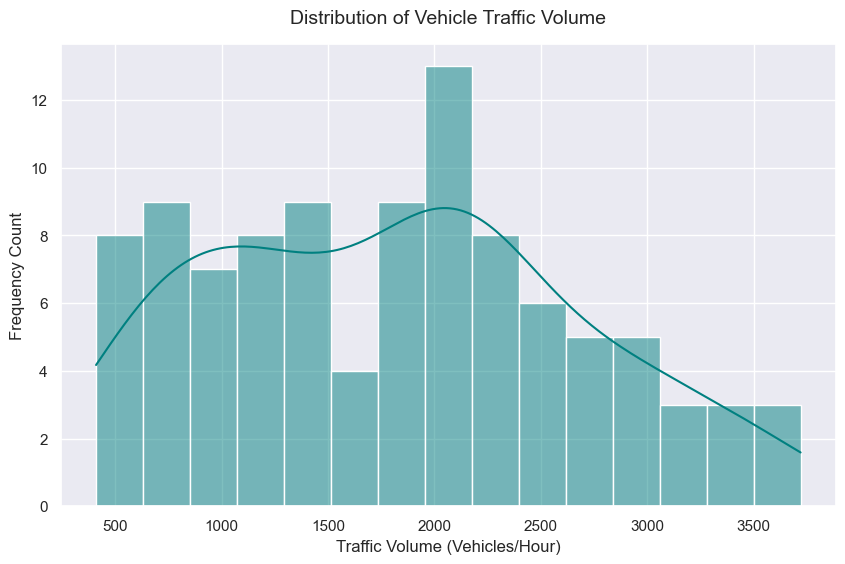

In [69]:
plt.figure() 
sns.histplot(df["Traffic_Volume"], bins=15, kde=True,
color="teal") 
plt.title("Distribution of Vehicle Traffic Volume",
fontsize=14, pad=15) 
plt.xlabel("Traffic Volume (Vehicles/Hour)",
fontsize=12) 
plt.ylabel("Frequency Count", fontsize=12) 
plt.show()

### Insight : The frequency distribution and spread of vehicles densities across all monitored corridors.These also shows the dramatic peak shift between empty night roads and saturated peak hours, pointing out that traffic is rarely average.

## H. Proportional Share of Congession Levels( Pie Chart).

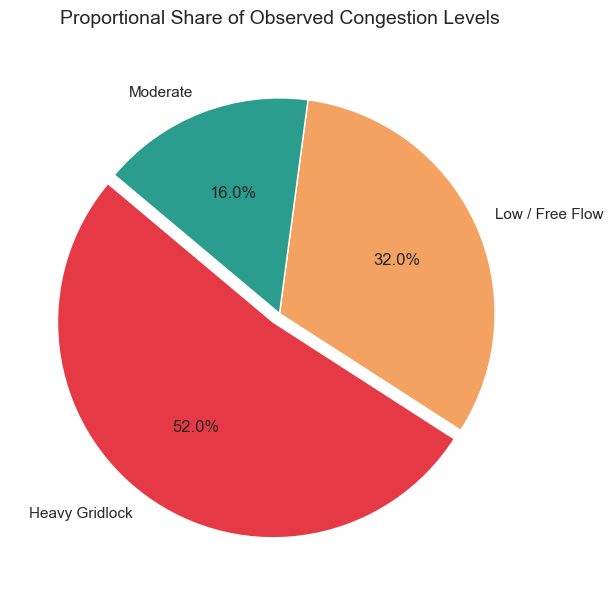

In [70]:
plt.figure(figsize=(7, 7)) 
congestion_counts = df["Congestion_Level"].value_counts() 
plt.pie( 
    congestion_counts,
    labels=congestion_counts.index, 
    autopct="%1.1f%%", 
    startangle=140,
    colors=["#e63946", "#f4a261", "#2a9d8f"], 
    explode=(0.05, 0, 0), )
plt.title("Proportional Share of Observed Congestion Levels", fontsize=14, pad=15) 
plt.show()

### Insight : These chart visualizess the overall breakdown of my dataset's classes (heavy Gridlock vs Moderate vs Low). 